In [14]:
import sys

sys.path.append('../src')

from data_loader import fetch_price_data, save_data, load_data
from analysis import compute_returns, summary_statistics, normality_test, rolling_stats, compare_assets
from plotting import plot_price_history, plot_returns_analysis, plot_qq

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
ticker = "SOL-USD"
df = fetch_price_data(ticker, period="2y", interval="1d")
save_data(df, ticker)
df.head()

[*********************100%***********************]  1 of 1 completed

Saved to ../data/SOL_USD.csv


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-08-05,129.864304,139.141464,110.609558,138.052689,14114308949
2024-08-06,144.090363,149.352966,129.788574,129.862946,5813459735
2024-08-07,144.632095,155.007797,142.746902,144.088211,5529725414
2024-08-08,162.930740,163.025909,142.019928,144.632477,5385642745
2024-08-09,156.457214,163.249481,151.226135,162.930740,3217916997


In [16]:
df = compute_returns(df)
df = rolling_stats(df, window=30)
df.tail()

Price,Close,High,Low,Open,Volume,Return,Log_Return,Rolling_Mean_30,Rolling_Vol_30
Date,,,,,,,,,
2026-08-01,71.866280,73.118652,70.694214,72.789398,1163302717,-0.012686,-0.012767,-0.003676,0.287135
2026-08-02,73.448822,74.094490,71.866486,71.866486,1052914463,0.022021,0.021782,-0.003618,0.288433
2026-08-03,73.473701,74.112488,71.959717,73.450745,1450637712,0.000339,0.000339,-0.003351,0.288390
2026-08-04,73.717758,74.342255,73.008110,73.473793,1454644591,0.003322,0.003316,-0.003148,0.289037
2026-08-05,74.239998,74.585205,73.393082,73.718048,1744738432,0.007084,0.007059,-0.003113,0.289340


In [17]:

stats_dict = summary_statistics(df)
for key, val in stats_dict.items():
    print(f"{key}: {float(val):.4f}")   


mean_daily_return: 0.0001
std_daily_return: 0.0406
annualised_return: 0.0137
annualised_vol: 0.6447
sharpe_ratio: 0.0213
skewness: 0.3405
kurtosis: 3.7161
max_drawdown: -0.7625
var_95: -0.0595


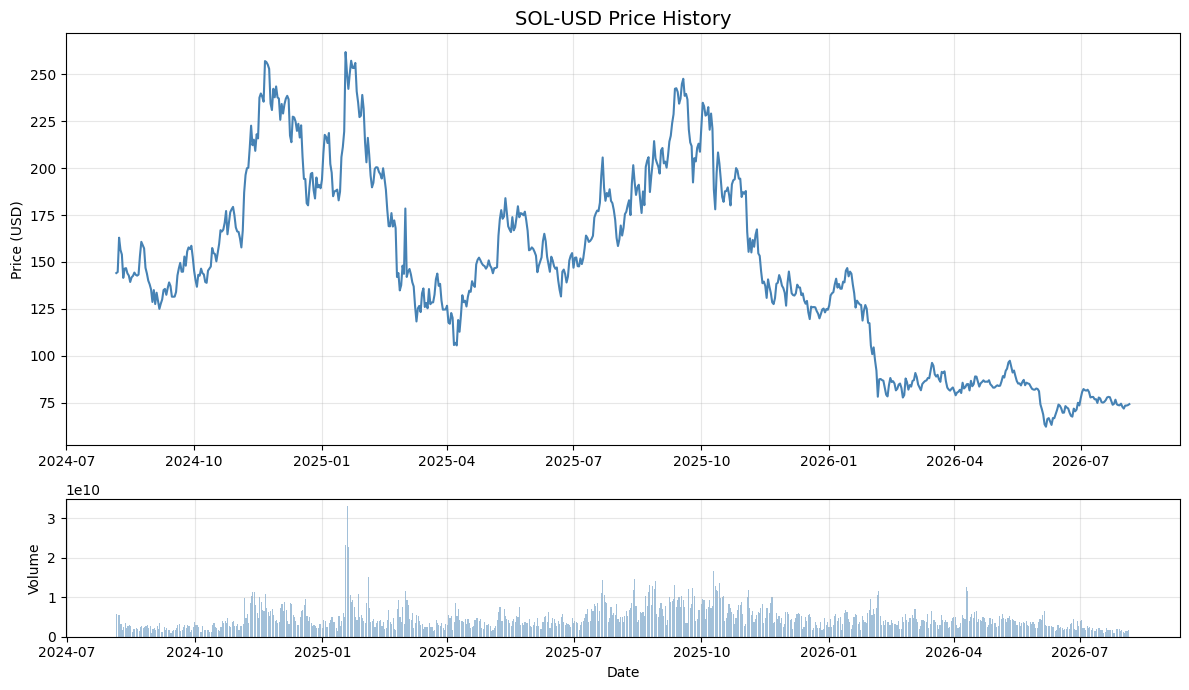

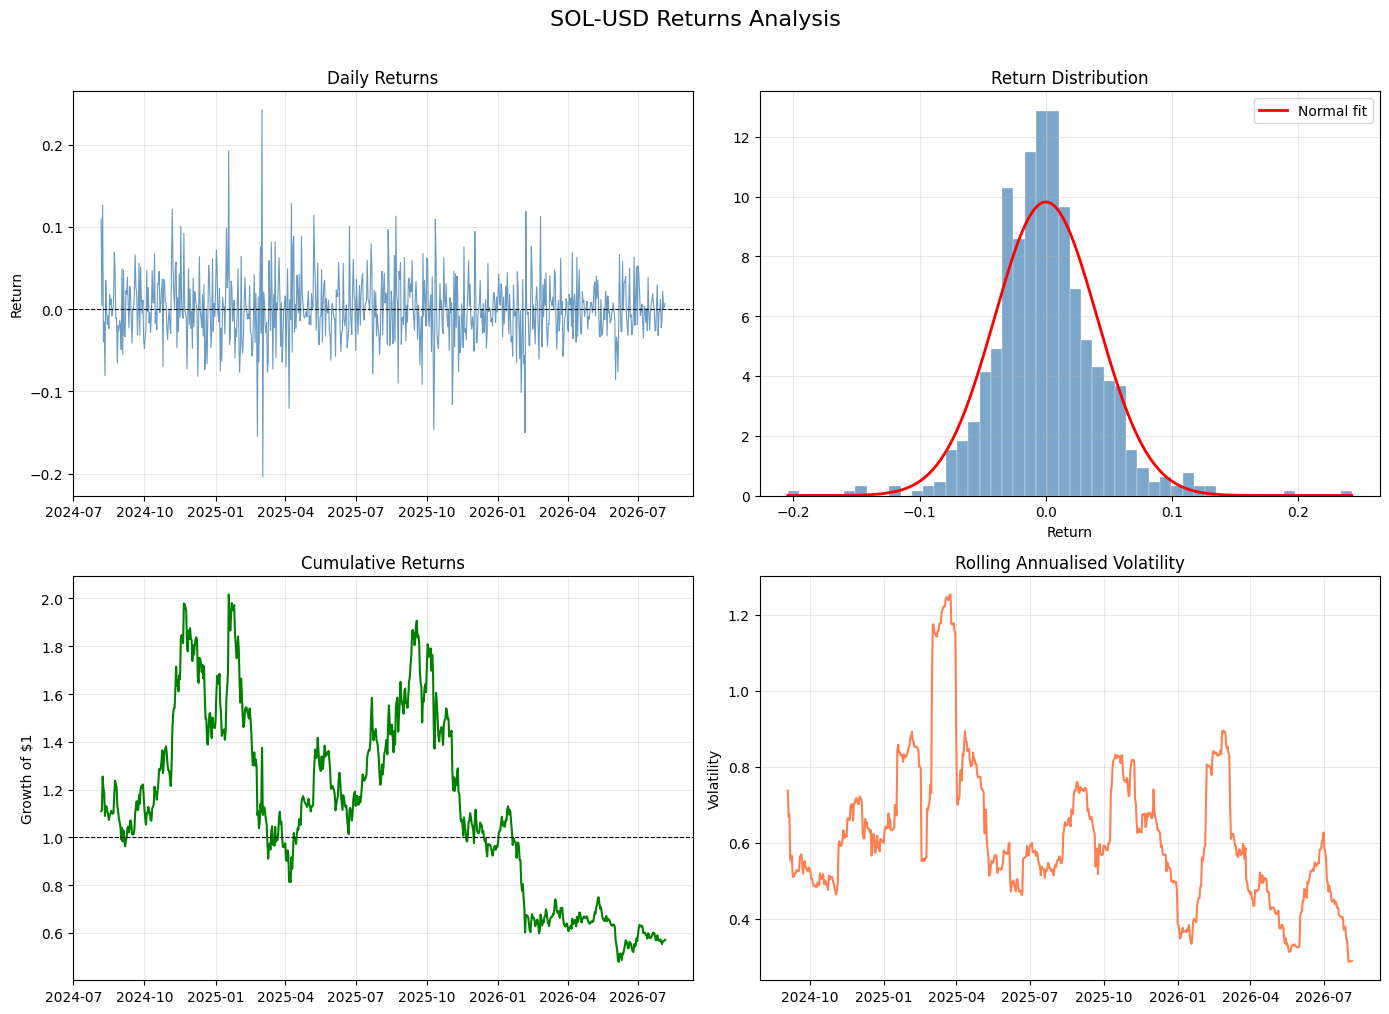

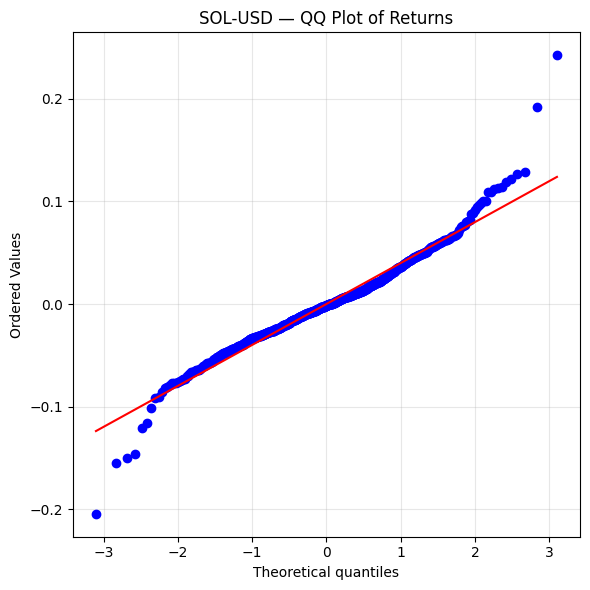

In [18]:
plot_price_history(df, ticker)
plot_returns_analysis(df, ticker)
plot_qq(df, ticker)

In [19]:
norm_test = normality_test(df)
print(f"Stastistic: {norm_test['statistic']:.4f}")
print(f"p-value: {norm_test['p_value']:.4f}")
print(f"Normal? : {norm_test['is_normal']}")

Stastistic: 82.4788
p-value: 0.0000
Normal? : False


In [20]:
tickers = [ 
    "BTC-USD",
    "SOL-USD",
    "ETH-USD",
    "AAPL",
    "SPY",
    "GLD"
]

In [21]:
ranking = compare_assets(tickers, period="2y")
ranking.round(4)

[*********************100%***********************]  1 of 1 completed

fetchingBTC-USD...
fetchingSOL-USD...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


fetchingETH-USD...
fetchingAAPL...


[*********************100%***********************]  1 of 1 completed


fetchingSPY...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

fetchingGLD...


,mean_daily_return,std_daily_return,annualised_return,annualised_vol,sharpe_ratio,skewness,kurtosis,max_drawdown,var_95
ticker,,,,,,,,,
GLD,0.0012,0.0149,0.3148,0.2364,1.3314,-0.8821,5.9162,-0.2640,-0.0227
SPY,0.0009,0.0106,0.2215,0.1680,1.3187,1.1028,21.3855,-0.1876,-0.0155
AAPL,0.0010,0.0181,0.2502,0.2879,0.8689,0.5952,12.1183,-0.3336,-0.0272
BTC-USD,0.0005,0.0238,0.1336,0.3777,0.3536,0.3050,4.5002,-0.5306,-0.0357
ETH-USD,0.0003,0.0366,0.0861,0.5808,0.1482,0.4748,3.8410,-0.6761,-0.0533
SOL-USD,0.0001,0.0406,0.0137,0.6447,0.0213,0.3405,3.7161,-0.7625,-0.0595


In [22]:
print("=== Asset Ranking by Sharpe Ratio ===\n")
for ticker, row in ranking.iterrows():
    print(f"{ticker:10s} | Sharpe: {float(row['sharpe_ratio']):6.3f} | "
    f"Ann. Return: {float(row['annualised_return']):7.3f} | "
    f"Volatility: {float(row['annualised_vol']):6.3f} | "
    f"MAX DD: {float(row['max_drawdown']):7.3f}")

=== Asset Ranking by Sharpe Ratio ===

GLD        | Sharpe:  1.331 | Ann. Return:   0.315 | Volatility:  0.236 | MAX DD:  -0.264
SPY        | Sharpe:  1.319 | Ann. Return:   0.221 | Volatility:  0.168 | MAX DD:  -0.188
AAPL       | Sharpe:  0.869 | Ann. Return:   0.250 | Volatility:  0.288 | MAX DD:  -0.334
BTC-USD    | Sharpe:  0.354 | Ann. Return:   0.134 | Volatility:  0.378 | MAX DD:  -0.531
ETH-USD    | Sharpe:  0.148 | Ann. Return:   0.086 | Volatility:  0.581 | MAX DD:  -0.676
SOL-USD    | Sharpe:  0.021 | Ann. Return:   0.014 | Volatility:  0.645 | MAX DD:  -0.763
